# Adaptive vs. Fixed FMM Benchmark

This notebook compares the current **adaptive-order / error-aware acceptance model**
against a **fixed-order baseline** in `jaccpot`.

It is split into two parts:

1. **Performance**: warmed runtime comparisons with a tree / traversal / M2L / total split.
2. **Accuracy**: direct-sum comparisons with Dehnen-style diagnostics based on per-particle
   relative acceleration errors and error distributions.

The current comparison uses the real-basis `accurate` preset and contrasts:

- `adaptive_order=False`, `max_order=4`
- `adaptive_order=True`, `p_gears=(2, 3, 4)`

Use the modes as follows:

- `tail_proxy`: validated high-performance default
- `dehnen_paper + tree_approx`: JAX-native paper-inspired comparison mode
- `dehnen_paper + exact`: reference-only geometry mode

The adaptive path uses the current solver-owned acceptance model:

- highest available order decides whether a pair is safe to accept,
- a relaxed geometric guard prevents pathological over-acceptance,
- the first passing order chooses the far-field work bucket.


In [1]:
import math
import pathlib
import sys
from dataclasses import dataclass
from types import MethodType

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = pathlib.Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "jaccpot").exists() else NOTEBOOK_DIR.parent
EXAMPLES_DIR = REPO_ROOT / "examples"
for path in (REPO_ROOT, EXAMPLES_DIR):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from benchmark_utils import generate_random_distribution, time_callable
from jaccpot.config import FMMAdvancedConfig, RuntimePolicyConfig
from jaccpot import FastMultipoleMethod
from yggdrax import DualTreeTraversalConfig
from jaccpot.runtime._adaptive_policy import (
    adaptive_pair_policy,
    adaptive_policy_tolerance,
    bucket_far_pairs_by_tag,
    dehnen_like_pair_error_by_order_from_degree_power,
    source_error_proxy_by_order_from_degree_power,
    source_power_by_degree_from_multipoles,
)
from jaccpot.runtime._interaction_cache import _build_dual_tree_artifacts
from jaccpot.runtime.reference import direct_sum as reference_direct_sum

print('jax:', jax.__version__)
print('device:', jax.devices()[0])


jax: 0.7.2
device: TFRT_CPU_0


## Benchmark Helpers

The stage-timing helpers below mirror the runtime split used by `bench/bench_fmm.py`:

- tree / upward preparation
- traversal construction
- M2L / downward preparation
- full end-to-end acceleration evaluation

The direct-sum helpers are only used for the smaller accuracy problem sizes because
that baseline scales as `O(N^2)`.


In [2]:
@dataclass(frozen=True)
class StageArtifacts:
    tree_artifacts: object
    runtime_overrides: object
    positions_arr: jax.Array
    masses_arr: jax.Array




def benchmark_runtime_config(
    *,
    process_block=128,
    max_interactions_per_node=131072,
    max_neighbors_per_leaf=262144,
    max_pair_queue=262144,
):
    return FMMAdvancedConfig(
        runtime=RuntimePolicyConfig(
            traversal_config=DualTreeTraversalConfig(
                process_block=process_block,
                max_interactions_per_node=max_interactions_per_node,
                max_neighbors_per_leaf=max_neighbors_per_leaf,
                max_pair_queue=max_pair_queue,
            )
        )
    )

def make_solver(*, adaptive_order: bool, theta: float, p_gears=(2, 3, 4),
                preset='accurate', basis='real', softening=1.0e-2,
                mac_force_scale_mode='prev', adaptive_error_model='tail_proxy',
                adaptive_eps=None, dehnen_geometry_mode='tree_approx', advanced=None):
    if advanced is None:
        advanced = benchmark_runtime_config()
    solver = FastMultipoleMethod(
        preset=preset,
        basis=basis,
        theta=theta,
        softening=softening,
        adaptive_order=adaptive_order,
        p_gears=tuple(int(v) for v in p_gears),
        mac_force_scale_mode=mac_force_scale_mode,
        adaptive_error_model=adaptive_error_model,
        adaptive_eps=adaptive_eps,
        dehnen_geometry_mode=dehnen_geometry_mode,
        advanced=advanced,
    )
    if adaptive_order and adaptive_error_model != 'dehnen_paper':
        original_build_policy_state = solver._impl._build_adaptive_policy_state

        def _compat_build_adaptive_policy_state(self, **kwargs):
            state = original_build_policy_state(**kwargs)
            dtype = state.target_accept_threshold.dtype
            dehnen_width = max(1, len(kwargs['p_gears']))
            num_nodes = int(kwargs['tree'].parent.shape[0])
            return state._replace(
                source_dehnen_power=jnp.zeros((num_nodes, dehnen_width), dtype=dtype),
                dehnen_binomial_masked_by_order=jnp.zeros((len(kwargs['p_gears']), dehnen_width), dtype=dtype),
                dehnen_exponent_by_order=jnp.zeros((len(kwargs['p_gears']), dehnen_width), dtype=jnp.int32),
            )

        solver._impl._build_adaptive_policy_state = MethodType(
            _compat_build_adaptive_policy_state,
            solver._impl,
        )
    return solver


def build_tree_and_upward(fmm, positions, masses, *, leaf_size, max_order):
    impl = fmm._impl
    positions_arr, masses_arr, _ = impl._prepare_state_input_arrays(positions, masses)
    runtime_overrides = impl._resolve_runtime_execution_overrides(
        num_particles=int(positions_arr.shape[0])
    )
    tree_artifacts = impl._prepare_state_tree_and_upward(
        positions_arr=positions_arr,
        masses_arr=masses_arr,
        bounds=None,
        leaf_size=int(leaf_size),
        max_order=int(max_order),
        refine_local_val=impl.refine_local,
        max_refine_levels_val=impl.max_refine_levels,
        aspect_threshold_val=impl.aspect_threshold,
        jit_tree_override=None,
        upward_center_mode=runtime_overrides.center_mode,
        allow_stateful_cache=False,
    )
    return StageArtifacts(
        tree_artifacts=tree_artifacts,
        runtime_overrides=runtime_overrides,
        positions_arr=positions_arr,
        masses_arr=masses_arr,
    )


def build_traversal(fmm, staged, *, theta):
    impl = fmm._impl
    tree_artifacts = staged.tree_artifacts
    runtime_overrides = staged.runtime_overrides
    pair_policy = None
    policy_state = None
    if impl.adaptive_order:
        pair_policy = adaptive_pair_policy
        dtype = tree_artifacts.positions_sorted.dtype
        error_model_name = getattr(impl, 'adaptive_error_model', 'tail_proxy')
        policy_state = impl._build_adaptive_policy_state(
            upward=tree_artifacts.upward,
            tree=tree_artifacts.tree,
            positions_sorted=tree_artifacts.positions_sorted,
            p_gears=impl.p_gears,
            force_scale_nodes=jnp.ones(
                (tree_artifacts.tree.parent.shape[0],),
                dtype=dtype,
            ),
            eps=jnp.asarray(
                impl.adaptive_eps
                if getattr(impl, 'adaptive_eps', None) is not None
                else adaptive_policy_tolerance(
                    theta=float(theta),
                    p_gears=impl.p_gears,
                    dtype=dtype,
                ),
                dtype=dtype,
            ),
            theta=jnp.asarray(float(theta), dtype=dtype),
            error_model_code=jnp.asarray(
                2
                if error_model_name == 'dehnen_paper'
                else (1 if error_model_name == 'dehnen_degree' else 0),
                dtype=jnp.int32,
            ),
            dehnen_geometry_mode=getattr(impl, 'dehnen_geometry_mode', 'tree'),
        )
        if error_model_name != 'dehnen_paper':
            # JAX traces all switch branches in adaptive_pair_policy, so keep
            # the Dehnen-paper placeholders shape-compatible even for tail_proxy.
            dehnen_width = max(1, len(impl.p_gears))
            num_nodes = int(tree_artifacts.tree.parent.shape[0])
            policy_state = policy_state._replace(
                source_dehnen_power=jnp.zeros((num_nodes, dehnen_width), dtype=dtype),
                dehnen_binomial_masked_by_order=jnp.zeros((len(impl.p_gears), dehnen_width), dtype=dtype),
                dehnen_exponent_by_order=jnp.zeros((len(impl.p_gears), dehnen_width), dtype=jnp.int32),
            )
    dual_artifacts, _ = _build_dual_tree_artifacts(
        tree_artifacts.tree,
        tree_artifacts.upward.geometry,
        theta=float(theta),
        mac_type=impl.mac_type,
        dehnen_radius_scale=impl.dehnen_radius_scale,
        cache_key=None,
        cache_entry=None,
        max_pair_queue=impl.max_pair_queue,
        pair_process_block=impl.pair_process_block,
        traversal_config=runtime_overrides.traversal_config,
        retry_logger=None,
        use_dense_interactions=impl.use_dense_interactions,
        grouped_interactions=runtime_overrides.grouped_interactions,
        grouped_chunk_size=runtime_overrides.m2l_chunk_size,
        pair_policy=pair_policy,
        policy_state=policy_state,
    )
    return dual_artifacts


def fresh_locals_template(fmm, staged, *, max_order):
    impl = fmm._impl
    tree_artifacts = staged.tree_artifacts
    return impl._build_locals_template_for_prepare_state(
        tree=tree_artifacts.tree,
        upward=tree_artifacts.upward,
        max_order=int(max_order),
        pos_sorted=tree_artifacts.positions_sorted,
    )


def adaptive_far_pairs_by_gear(fmm, dual_artifacts):
    if not fmm._impl.adaptive_order:
        return None
    traversal_result = dual_artifacts.traversal_result
    far_total = int(traversal_result.far_pair_count)
    return bucket_far_pairs_by_tag(
        jnp.asarray(traversal_result.interaction_sources[:far_total], dtype=jnp.int32),
        jnp.asarray(traversal_result.interaction_targets[:far_total], dtype=jnp.int32),
        jnp.asarray(traversal_result.interaction_tags[:far_total], dtype=jnp.int32),
        num_tags=len(fmm._impl.p_gears),
    )


def run_m2l_downward(fmm, staged, dual_artifacts, *, theta, max_order):
    impl = fmm._impl
    tree_artifacts = staged.tree_artifacts
    runtime_overrides = staged.runtime_overrides

    (
        interactions,
        _neighbor_list,
        _traversal_result,
        dense_buffers,
        grouped_buffers,
        grouped_segment_starts,
        grouped_segment_lengths,
        grouped_segment_class_ids,
        grouped_segment_sort_permutation,
        grouped_segment_group_ids,
        grouped_segment_unique_targets,
    ) = impl._unpack_dual_tree_artifacts(dual_artifacts)

    locals_template = fresh_locals_template(fmm, staged, max_order=max_order)
    far_pairs_by_gear = adaptive_far_pairs_by_gear(fmm, dual_artifacts)

    return impl._prepare_downward_with_artifacts(
        tree=tree_artifacts.tree,
        upward=tree_artifacts.upward,
        theta_val=float(theta),
        locals_template=locals_template,
        interactions=interactions,
        runtime_m2l_chunk_size=runtime_overrides.m2l_chunk_size,
        runtime_l2l_chunk_size=runtime_overrides.l2l_chunk_size,
        runtime_traversal_config=runtime_overrides.traversal_config,
        record_retry=lambda _: None,
        dense_buffers=dense_buffers,
        grouped_interactions=runtime_overrides.grouped_interactions,
        grouped_buffers=grouped_buffers,
        grouped_segment_starts=grouped_segment_starts,
        grouped_segment_lengths=grouped_segment_lengths,
        grouped_segment_class_ids=grouped_segment_class_ids,
        grouped_segment_sort_permutation=grouped_segment_sort_permutation,
        grouped_segment_group_ids=grouped_segment_group_ids,
        grouped_segment_unique_targets=grouped_segment_unique_targets,
        farfield_mode=runtime_overrides.farfield_mode,
        far_pairs_by_gear=far_pairs_by_gear,
        adaptive_order=impl.adaptive_order,
        p_gears=impl.p_gears,
    )


def benchmark_runtime_case(*, n, theta=0.5, leaf_size=16, max_order=4,
                           warmup=3, runs=2, dtype=jnp.float64,
                           p_gears=(2, 3, 4), seed=0, advanced=None):
    if advanced is None:
        advanced = benchmark_runtime_config()
    key = jax.random.PRNGKey(seed)
    positions, masses, _ = generate_random_distribution(
        n,
        key=key,
        dtype=dtype,
    )
    results = {}
    for label, adaptive in [('fixed', False), ('adaptive', True)]:
        solver = make_solver(
            adaptive_order=adaptive,
            theta=theta,
            p_gears=p_gears,
            advanced=advanced,
        )
        tree_timing = time_callable(
            build_tree_and_upward,
            solver,
            positions,
            masses,
            leaf_size=leaf_size,
            max_order=max_order,
            warmup=warmup,
            runs=runs,
        )
        staged = tree_timing.result
        traversal_timing = time_callable(
            build_traversal,
            solver,
            staged,
            theta=theta,
            warmup=warmup,
            runs=runs,
        )
        dual_artifacts = traversal_timing.result
        m2l_timing = time_callable(
            run_m2l_downward,
            solver,
            staged,
            dual_artifacts,
            theta=theta,
            max_order=max_order,
            warmup=warmup,
            runs=runs,
        )
        total_timing = time_callable(
            lambda pos, mass: solver.compute_accelerations(
                pos,
                mass,
                leaf_size=leaf_size,
                max_order=max_order,
            ),
            positions,
            masses,
            warmup=warmup,
            runs=runs,
        )
        traversal_result = dual_artifacts.traversal_result
        gear_counts = tuple(int(v) for v in getattr(solver._impl, '_recent_far_pairs_by_gear_counts', tuple()))
        results[label] = {
            'tree_s': tree_timing.mean,
            'traversal_s': traversal_timing.mean,
            'm2l_s': m2l_timing.mean,
            'total_s': total_timing.mean,
            'far_pairs': int(traversal_result.far_pair_count),
            'near_pairs': int(traversal_result.near_pair_count),
            'gear_counts': gear_counts,
        }
    return results


def direct_sum_accelerations(positions, masses, *, softening=1.0e-2, G=1.0):
    return jax.vmap(
        lambda x: reference_direct_sum(
            positions,
            masses,
            x,
            G=G,
            softening=softening,
        )
    )(positions)


def relative_acceleration_errors(acc, ref, *, eps=1.0e-12):
    acc = jnp.asarray(acc)
    ref = jnp.asarray(ref)
    abs_err = jnp.linalg.norm(acc - ref, axis=1)
    ref_mag = jnp.linalg.norm(ref, axis=1)
    rel_err = abs_err / jnp.maximum(ref_mag, eps)
    return rel_err, abs_err, ref_mag


def summarize_errors(rel_err):
    rel_np = np.asarray(rel_err)
    return {
        'median': float(np.median(rel_np)),
        'p90': float(np.quantile(rel_np, 0.90)),
        'p99': float(np.quantile(rel_np, 0.99)),
        'max': float(np.max(rel_np)),
    }


def empirical_cdf(values):
    arr = np.sort(np.asarray(values))
    frac = (np.arange(arr.size) + 1) / arr.size
    return arr, frac


## Runtime Benchmark

The next cell runs a warmed benchmark on a small list of `N` values and reports:

- tree/upward time
- traversal time
- M2L/downward preparation time
- total acceleration-evaluation time
- far/near interaction counts
- adaptive gear counts

These timings are intended to compare **fixed** and **adaptive** criteria on the
same particle realization and solver settings.


In [3]:
theta = 0.5
leaf_size = 16
max_order = 4
p_gears = (2, 3, 4)
warmup = 3
runs = 2
n_values = (4_000, 16_000)

runtime_rows = []
for n in n_values:
    stats = benchmark_runtime_case(
        n=n,
        theta=theta,
        leaf_size=leaf_size,
        max_order=max_order,
        warmup=warmup,
        runs=runs,
        dtype=jnp.float64,
        p_gears=p_gears,
        seed=0,
        advanced=benchmark_runtime_config(),
    )
    for label, values in stats.items():
        runtime_rows.append({'n': n, 'mode': label, **values})

runtime_rows


[{'n': 4000,
  'mode': 'fixed',
  'tree_s': 0.4088079580105841,
  'traversal_s': 0.22614916693419218,
  'm2l_s': 0.0413173750275746,
  'total_s': 0.6381138750584796,
  'far_pairs': 10586,
  'near_pairs': 40548,
  'gear_counts': ()},
 {'n': 4000,
  'mode': 'adaptive',
  'tree_s': 0.41215174994431436,
  'traversal_s': 0.2081428535748273,
  'm2l_s': 0.022212708019651473,
  'total_s': 1.4839884375687689,
  'far_pairs': 6110,
  'near_pairs': 24058,
  'gear_counts': (1369, 3530, 1211)},
 {'n': 16000,
  'mode': 'fixed',
  'tree_s': 0.8391543960897252,
  'traversal_s': 1.7663964165840298,
  'm2l_s': 0.4351982915541157,
  'total_s': 2.233496187487617,
  'far_pairs': 159166,
  'near_pairs': 272490,
  'gear_counts': ()},
 {'n': 16000,
  'mode': 'adaptive',
  'tree_s': 0.8290069164941087,
  'traversal_s': 1.5539156454615295,
  'm2l_s': 0.08777306252159178,
  'total_s': 3.0080780829302967,
  'far_pairs': 51174,
  'near_pairs': 144018,
  'gear_counts': (28239, 18356, 4579)}]

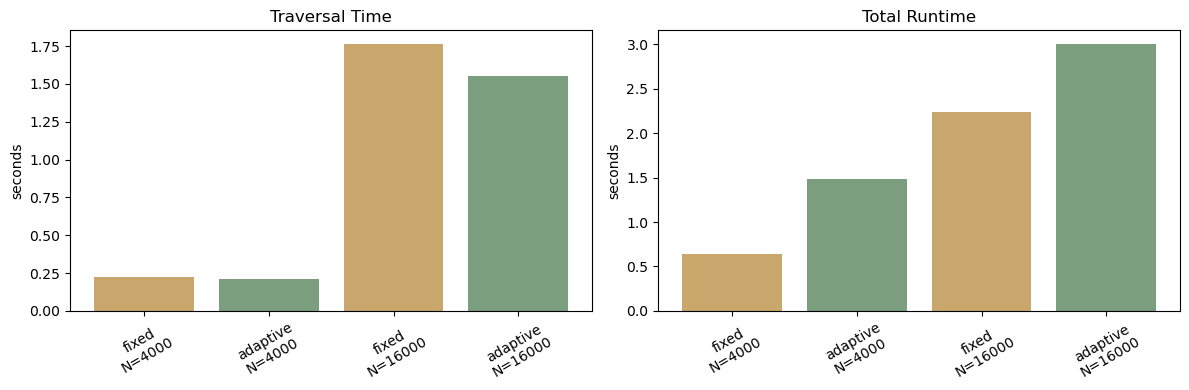

mode=fixed    N=4000   tree=0.409s traversal=0.226s m2l=0.041s total=0.638s far=10586    near=40548    gears=()
mode=adaptive N=4000   tree=0.412s traversal=0.208s m2l=0.022s total=1.484s far=6110     near=24058    gears=(1369, 3530, 1211)
mode=fixed    N=16000  tree=0.839s traversal=1.766s m2l=0.435s total=2.233s far=159166   near=272490   gears=()
mode=adaptive N=16000  tree=0.829s traversal=1.554s m2l=0.088s total=3.008s far=51174    near=144018   gears=(28239, 18356, 4579)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [f"{row['mode']}\nN={row['n']}" for row in runtime_rows]
traversal = [row['traversal_s'] for row in runtime_rows]
total = [row['total_s'] for row in runtime_rows]

axes[0].bar(labels, traversal, color=['#7a9e7e' if row['mode'] == 'adaptive' else '#c9a66b' for row in runtime_rows])
axes[0].set_title('Traversal Time')
axes[0].set_ylabel('seconds')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(labels, total, color=['#7a9e7e' if row['mode'] == 'adaptive' else '#c9a66b' for row in runtime_rows])
axes[1].set_title('Total Runtime')
axes[1].set_ylabel('seconds')
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

for row in runtime_rows:
    print(
        f"mode={row['mode']:<8} N={row['n']:<6d} tree={row['tree_s']:.3f}s "
        f"traversal={row['traversal_s']:.3f}s m2l={row['m2l_s']:.3f}s total={row['total_s']:.3f}s "
        f"far={row['far_pairs']:<8d} near={row['near_pairs']:<8d} gears={row['gear_counts']}"
    )


## Accuracy Diagnostics

For the accuracy comparison we use a smaller problem and compute a direct-sum
reference acceleration at every particle position.

The plots and summaries below are intentionally Dehnen-like:

- **relative acceleration error per particle**
- **distribution / cumulative fraction of errors**
- **percentile summaries** (`median`, `p90`, `p99`, `max`)

Here the relative error is

\[

rac{\|a_\mathrm{FMM} - a_\mathrm{ref}\|}{\|a_\mathrm{ref}\| + 
arepsilon}.
\]


In [5]:
n_accuracy = 512
theta_accuracy = 0.5
leaf_size_accuracy = 16
softening = 1.0e-2
dehnen_accuracy_eps = 1.0e-3
dehnen_accuracy_geometry_mode = 'tree_approx'
key = jax.random.PRNGKey(123)
positions_acc, masses_acc, _ = generate_random_distribution(
    n_accuracy,
    key=key,
    dtype=jnp.float64,
)

In [6]:
advanced_accuracy = benchmark_runtime_config()

accuracy_case_specs = [
    {
        'label': 'fixed',
        'adaptive_order': False,
        'solver_kwargs': {},
    },
    {
        'label': 'adaptive',
        'adaptive_order': True,
        'solver_kwargs': {
            'p_gears': p_gears,
            'adaptive_error_model': 'tail_proxy',
            'mac_force_scale_mode': 'prev',
        },
    },
    {
        'label': 'dehnen_paper_tree_approx',
        'adaptive_order': True,
        'solver_kwargs': {
            'p_gears': p_gears,
            'adaptive_error_model': 'dehnen_paper',
            'mac_force_scale_mode': 'paper',
            'adaptive_eps': dehnen_accuracy_eps,
            'dehnen_geometry_mode': dehnen_accuracy_geometry_mode,
        },
    },
]

ref_timing = time_callable(
    direct_sum_accelerations,
    positions_acc,
    masses_acc,
    softening=softening,
    warmup=1,
    runs=1,
)
acc_ref = ref_timing.result

accuracy_rows = []
accuracy_errors = {}
accuracy_solvers = {}
for spec in accuracy_case_specs:
    solver = make_solver(
        adaptive_order=spec['adaptive_order'],
        theta=theta_accuracy,
        softening=softening,
        advanced=advanced_accuracy,
        **spec['solver_kwargs'],
    )
    timing = time_callable(
        lambda pos, mass, solver=solver: solver.compute_accelerations(
            pos,
            mass,
            leaf_size=leaf_size_accuracy,
            max_order=max_order,
        ),
        positions_acc,
        masses_acc,
        warmup=2,
        runs=2,
    )
    rel_err, abs_err, ref_mag = relative_acceleration_errors(timing.result, acc_ref)
    row = {
        'label': spec['label'],
        'runtime_s': float(timing.mean),
        'gear_counts': tuple(int(v) for v in getattr(solver._impl, '_recent_far_pairs_by_gear_counts', ())),
        **summarize_errors(rel_err),
    }
    accuracy_rows.append(row)
    accuracy_errors[spec['label']] = {
        'rel': rel_err,
        'abs': abs_err,
    }
    accuracy_solvers[spec['label']] = solver

rel_fixed = accuracy_errors['fixed']['rel']
rel_adaptive = accuracy_errors['adaptive']['rel']
rel_dehnen = accuracy_errors['dehnen_paper_tree_approx']['rel']
summary_fixed = next(row for row in accuracy_rows if row['label'] == 'fixed')
summary_adaptive = next(row for row in accuracy_rows if row['label'] == 'adaptive')
summary_dehnen = next(row for row in accuracy_rows if row['label'] == 'dehnen_paper_tree_approx')

print('direct sum runtime:', ref_timing.mean)
for row in accuracy_rows:
    print(row['label'], 'runtime:', row['runtime_s'])
    print(row['label'], 'summary:', {k: row[k] for k in ('median', 'p90', 'p99', 'max')})
    if row['gear_counts']:
        print(row['label'], 'gear counts:', row['gear_counts'])

accuracy_rows


direct sum runtime: 0.0009048329666256905
fixed runtime: 0.41342768794856966
fixed summary: {'median': 5.933983868191918e-16, 'p90': 2.612284499734095e-15, 'p99': 0.01203744562511322, 'max': 0.030395226301822564}
adaptive runtime: 0.448385062511079
adaptive summary: {'median': 9.512663897916224e-16, 'p90': 0.028540494767430324, 'p99': 0.11630363789360469, 'max': 0.2447962026611868}
adaptive gear counts: (0, 0, 12)
dehnen_paper_tree_approx runtime: 0.7445342915598303
dehnen_paper_tree_approx summary: {'median': 6.04274178426068e-16, 'p90': 6.687816729730872e-15, 'p99': 0.015486104883404368, 'max': 0.03253402951227099}
dehnen_paper_tree_approx gear counts: (0, 0, 4)


[{'label': 'fixed',
  'runtime_s': 0.41342768794856966,
  'gear_counts': (),
  'median': 5.933983868191918e-16,
  'p90': 2.612284499734095e-15,
  'p99': 0.01203744562511322,
  'max': 0.030395226301822564},
 {'label': 'adaptive',
  'runtime_s': 0.448385062511079,
  'gear_counts': (0, 0, 12),
  'median': 9.512663897916224e-16,
  'p90': 0.028540494767430324,
  'p99': 0.11630363789360469,
  'max': 0.2447962026611868},
 {'label': 'dehnen_paper_tree_approx',
  'runtime_s': 0.7445342915598303,
  'gear_counts': (0, 0, 4),
  'median': 6.04274178426068e-16,
  'p90': 6.687816729730872e-15,
  'p99': 0.015486104883404368,
  'max': 0.03253402951227099}]

In [7]:
thresholds = (1e-4, 1e-3, 1e-2, 1e-1)
for row in accuracy_rows:
    rel_np = np.asarray(accuracy_errors[row['label']]['rel'])
    fractions = {thr: float(np.mean(rel_np <= thr)) for thr in thresholds}
    print(row['label'], fractions)


fixed {0.0001: 0.9375, 0.001: 0.94140625, 0.01: 0.98046875, 0.1: 1.0}
adaptive {0.0001: 0.6875, 0.001: 0.6875, 0.01: 0.712890625, 0.1: 0.98046875}
dehnen_paper_tree_approx {0.0001: 0.90625, 0.001: 0.91015625, 0.01: 0.939453125, 0.1: 1.0}


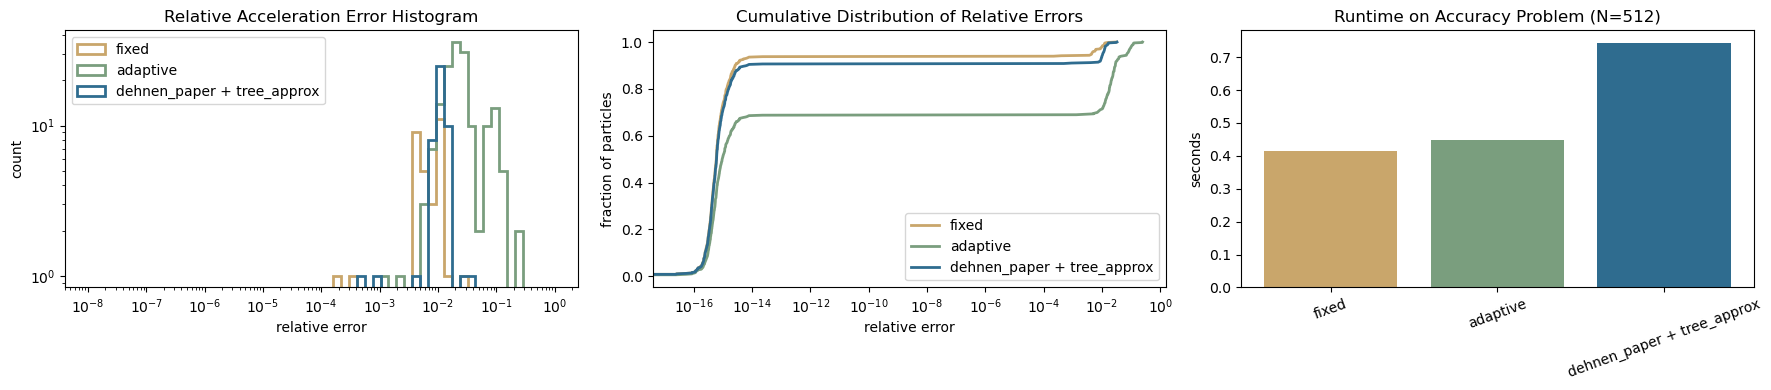

In [8]:
accuracy_colors = {
    'fixed': '#c9a66b',
    'adaptive': '#7a9e7e',
    'dehnen_paper_tree_approx': '#2f6c8f',
}
accuracy_display_labels = {
    'fixed': 'fixed',
    'adaptive': 'adaptive',
    'dehnen_paper_tree_approx': 'dehnen_paper + tree_approx',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

bins = np.logspace(-8, 0, 60)
for row in accuracy_rows:
    label = row['label']
    rel = np.asarray(accuracy_errors[label]['rel'])
    axes[0].hist(
        rel,
        bins=bins,
        histtype='step',
        linewidth=2,
        color=accuracy_colors[label],
        label=accuracy_display_labels[label],
    )
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Relative Acceleration Error Histogram')
axes[0].set_xlabel('relative error')
axes[0].set_ylabel('count')
axes[0].legend()

for row in accuracy_rows:
    label = row['label']
    x_vals, y_vals = empirical_cdf(accuracy_errors[label]['rel'])
    axes[1].plot(
        x_vals,
        y_vals,
        label=accuracy_display_labels[label],
        linewidth=2,
        color=accuracy_colors[label],
    )
axes[1].set_xscale('log')
axes[1].set_title('Cumulative Distribution of Relative Errors')
axes[1].set_xlabel('relative error')
axes[1].set_ylabel('fraction of particles')
axes[1].legend()

runtime_labels = [accuracy_display_labels[row['label']] for row in accuracy_rows]
runtime_vals = [row['runtime_s'] for row in accuracy_rows]
runtime_colors = [accuracy_colors[row['label']] for row in accuracy_rows]
axes[2].bar(runtime_labels, runtime_vals, color=runtime_colors)
axes[2].set_title(f'Runtime on Accuracy Problem (N={n_accuracy})')
axes[2].set_ylabel('seconds')
axes[2].tick_params(axis='x', rotation=20)

fig.tight_layout()
plt.show()


## Adaptive Error-Model Sweep

This sweep compares the validated default `tail_proxy` model against tuned `dehnen_paper` settings using the JAX-native `tree_approx` geometry mode.

Current Pareto result on this branch:

- `tail_proxy` remains the fastest validated default
- `dehnen_paper + tree_approx` buys a large accuracy improvement
- even after the recent JAX-native geometry and prepass optimizations, `dehnen_paper` is still slower on the warmed 4k runtime case
- loosening `adaptive_eps` moves `dehnen_paper` toward the `tail_proxy` error regime, but it still does not beat `tail_proxy` on runtime

So this section is best read as a runtime-vs-error tradeoff sweep, not as evidence that `dehnen_paper` is already the new default.


In [9]:
theta_sweep = 0.6
sweep_cases = [
    ('tail_proxy', None),
    ('dehnen_paper', 1.0e-4),
    ('dehnen_paper', 3.0e-4),
    ('dehnen_paper', 1.0e-3),
    ('dehnen_paper', 3.0e-3),
    ('dehnen_paper', 1.0e-2),
]
sweep_rows = []
for error_model, adaptive_eps in sweep_cases:
    solver = make_solver(
        adaptive_order=True,
        theta=theta_sweep,
        softening=softening,
        p_gears=p_gears,
        adaptive_error_model=error_model,
        adaptive_eps=adaptive_eps,
        advanced=benchmark_runtime_config(),
    )
    runtime_timing = time_callable(
        lambda pos, mass: solver.compute_accelerations(pos, mass, leaf_size=leaf_size_accuracy, max_order=max_order),
        positions_acc,
        masses_acc,
        warmup=2,
        runs=2,
    )
    rel_err, _, _ = relative_acceleration_errors(runtime_timing.result, acc_ref)
    row = {
        'error_model': error_model,
        'adaptive_eps': adaptive_eps,
        'runtime_s': float(runtime_timing.mean),
        **summarize_errors(rel_err),
        'gear_counts': tuple(int(v) for v in solver._impl._recent_far_pairs_by_gear_counts),
    }
    sweep_rows.append(row)

sweep_rows


[{'error_model': 'tail_proxy',
  'adaptive_eps': None,
  'runtime_s': 0.45655710401479155,
  'median': 0.043188599214510556,
  'p90': 0.16634719955074165,
  'p99': 0.3623701166437552,
  'max': 0.5785326007258543,
  'gear_counts': (1, 4, 37)},
 {'error_model': 'dehnen_paper',
  'adaptive_eps': 0.0001,
  'runtime_s': 0.503816333366558,
  'median': 5.49622265704924e-16,
  'p90': 1.799007415597721e-15,
  'p99': 7.253813221035554e-15,
  'max': 2.294260404853091e-14,
  'gear_counts': (0, 0, 0)},
 {'error_model': 'dehnen_paper',
  'adaptive_eps': 0.0003,
  'runtime_s': 0.5037921459879726,
  'median': 5.49622265704924e-16,
  'p90': 1.799007415597721e-15,
  'p99': 7.253813221035554e-15,
  'max': 2.294260404853091e-14,
  'gear_counts': (0, 0, 0)},
 {'error_model': 'dehnen_paper',
  'adaptive_eps': 0.001,
  'runtime_s': 0.5122251875000075,
  'median': 6.04274178426068e-16,
  'p90': 6.687816729730872e-15,
  'p99': 0.015486104883404368,
  'max': 0.03253402951227099,
  'gear_counts': (0, 0, 4)},
 {'

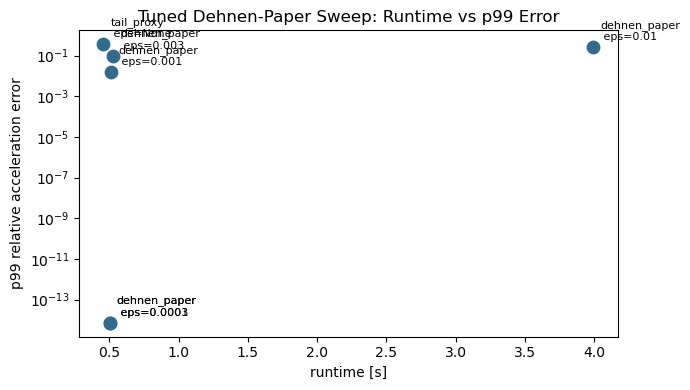

In [10]:
labels = [f"{row['error_model']}\n eps={row['adaptive_eps']}" for row in sweep_rows]
runtime_vals = [row['runtime_s'] for row in sweep_rows]
p99_vals = [row['p99'] for row in sweep_rows]
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(runtime_vals, p99_vals, s=80, color='#2f6c8f')
for label, x, y in zip(labels, runtime_vals, p99_vals):
    ax.annotate(label, (x, y), textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xlabel('runtime [s]')
ax.set_ylabel('p99 relative acceleration error')
ax.set_xscale('linear')
ax.set_yscale('log')
ax.set_title('Tuned Dehnen-Paper Sweep: Runtime vs p99 Error')
fig.tight_layout()
plt.show()


## Estimator Comparison

This section compares the **current runtime proxy** against an **experimental degree-weighted Dehnen-like estimator** on the same source nodes and a simple range of opening factors. It does not change the runtime path; it is only a diagnostic to show how the two estimators behave.

In [11]:
tuning_n = 2048
tuning_leaf_size = 16
tuning_max_order = 4
tuning_key = jax.random.PRNGKey(321)
positions_tune, masses_tune, _ = generate_random_distribution(
    tuning_n,
    key=tuning_key,
    dtype=jnp.float64,
)

diag_solver = make_solver(
    adaptive_order=True,
    theta=0.5,
    p_gears=(2, 3, 4),
    advanced=benchmark_runtime_config(),
)
diag_staged = build_tree_and_upward(
    diag_solver,
    positions_tune,
    masses_tune,
    leaf_size=tuning_leaf_size,
    max_order=tuning_max_order,
)
degree_power = source_power_by_degree_from_multipoles(
    multipole_packed=diag_staged.tree_artifacts.upward.multipoles.packed,
)
proxy_runtime = source_error_proxy_by_order_from_degree_power(
    degree_power=degree_power,
    p_gears=(2, 3, 4),
)
opening_grid = jnp.asarray([0.2, 0.35, 0.5, 0.65], dtype=proxy_runtime.dtype)
estimator_rows = []
for opening in opening_grid:
    est = dehnen_like_pair_error_by_order_from_degree_power(
        degree_power=degree_power[:64],
        opening=jnp.full((64,), opening, dtype=proxy_runtime.dtype),
        order_values=jnp.asarray((2, 3, 4), dtype=jnp.int32),
    )
    estimator_rows.append((float(opening), np.mean(np.asarray(est), axis=0)))

print('runtime proxy mean by gear:', np.mean(np.asarray(proxy_runtime[:64]), axis=0))
for opening, values in estimator_rows:
    print(f'opening={opening:.2f} dehnen-like mean by gear={values}')


runtime proxy mean by gear: [1.84896478 1.00855389 0.        ]
opening=0.20 dehnen-like mean by gear=[0.02695038 0.00806843 0.        ]
opening=0.35 dehnen-like mean by gear=[0.11491529 0.04324175 0.        ]
opening=0.50 dehnen-like mean by gear=[0.29259177 0.12606924 0.        ]
opening=0.65 dehnen-like mean by gear=[0.58528423 0.27697411 0.        ]


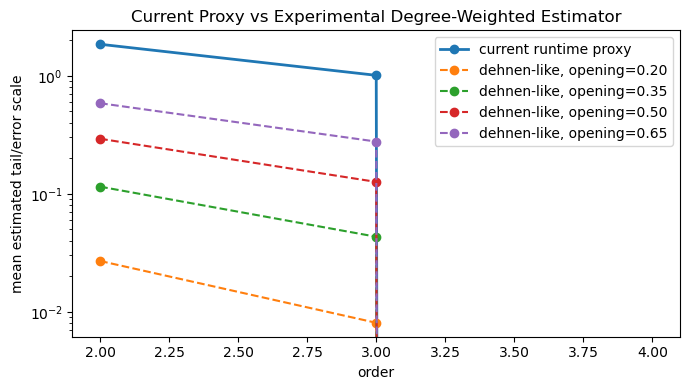

In [12]:
runtime_mean = np.mean(np.asarray(proxy_runtime[:64]), axis=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot((2, 3, 4), runtime_mean, marker='o', linewidth=2, label='current runtime proxy')
for opening, values in estimator_rows:
    ax.plot((2, 3, 4), values, marker='o', linestyle='--', label=f'dehnen-like, opening={opening:.2f}')
ax.set_yscale('log')
ax.set_xlabel('order')
ax.set_ylabel('mean estimated tail/error scale')
ax.set_title('Current Proxy vs Experimental Degree-Weighted Estimator')
ax.legend(loc='best')
fig.tight_layout()
plt.show()


## Interpreting the Results

A useful reading of this notebook is:

- **Performance section**:
  compare whether adaptive acceptance reduces traversal and/or total time relative
  to the fixed-order baseline.
- **Accuracy section**:
  compare whether adaptive acceptance preserves the same relative acceleration-error
  distribution shape and percentiles.

If adaptive is working well, you should typically see:

- lower or comparable total runtime,
- a shifted gear distribution instead of everything landing in the highest order,
- relative error percentiles that remain close to the fixed-order baseline.

If adaptive starts over-accepting, the histogram and percentile diagnostics will
usually show it immediately in the high-error tail.


## Dehnen Geometry Sweep

The paper-mode geometry supports four variants:

- `exact`: exact smallest-enclosing sphere for every node
- `tree`: exact leaf spheres plus upward sphere merges
- `tree_approx`: approximate leaf spheres plus upward sphere merges
- `runtime`: legacy runtime bounds

Current practical interpretation:

- `exact`: reference-only
- `tree`: intermediate paper-aligned mode
- `tree_approx`: recommended JAX-native paper geometry mode

On the current branch, the biggest geometry wins already happened when we moved away from global exact SES and then moved the approximate leaf spheres into JAX. The remaining performance gap for `dehnen_paper` is no longer dominated by geometry construction.

Measured on the current branch, `tree` and `tree_approx` radii are clearly tighter than the legacy `runtime` bounds. That means the remaining excess work in `dehnen_paper` is not caused by oversized cells; it is caused by the stricter paper-style acceptance rule and thresholding.


In [13]:
theta_geom = 0.6
leaf_size_geom = 8
max_order_geom = 4
n_geom = 4_000
warmup_geom = 2
runs_geom = 2
advanced_geom = benchmark_runtime_config()

positions_geom, masses_geom, _ = generate_random_distribution(
    n_geom,
    key=jax.random.PRNGKey(7),
    dtype=jnp.float64,
)

geometry_rows = []
for mode in ('exact', 'tree', 'tree_approx'):
    solver = make_solver(
        adaptive_order=False,
        theta=theta_geom,
        adaptive_error_model='dehnen_paper',
        adaptive_eps=1.0e-3,
        mac_force_scale_mode='paper',
        dehnen_geometry_mode=mode,
        advanced=advanced_geom,
    )
    timing = time_callable(
        lambda pos, mass: solver.compute_accelerations(
            pos, mass, leaf_size=leaf_size_geom, max_order=max_order_geom
        ),
        positions_geom,
        masses_geom,
        warmup=warmup_geom,
        runs=runs_geom,
    )
    geometry_rows.append({'geometry_mode': mode, 'total_s': timing.mean})

geometry_rows


[{'geometry_mode': 'exact', 'total_s': 10.240324186976068},
 {'geometry_mode': 'tree', 'total_s': 2.6167157291201875},
 {'geometry_mode': 'tree_approx', 'total_s': 2.507847166969441}]

### Further Speed-Up Options for the Dehnen Tree Geometry Modes

Current ranking:

1. `exact`: reference-only, too expensive for runtime use
2. `tree`: paper-aligned but slower than `tree_approx`
3. `tree_approx`: fastest JAX-native paper geometry mode

What is already done on this branch:

1. approximate leaf spheres are batched in JAX
2. upward sphere merging is already JAX-friendly
3. node force-scale reduction is JAX-native
4. paper prepass now reuses the current tree instead of rebuilding full state recursively

So the next likely bottleneck is not geometry micro-optimization. The remaining work is in the paper acceptance / threshold model itself.

A tighter cell geometry by itself should usually reduce work for a geometric MAC, because smaller radii make pair acceptance easier. On this branch we still see more total work under `dehnen_paper`, which indicates that the dominant effect is not geometry size but extra refinement triggered by the paper error criterion. When a parent pair fails that stricter criterion, the walk descends and can create many child pairs; some of those become extra far-field interactions while others bottom out as extra near-field work.


## Force-Scale Mode Interpretation

The adaptive modes in this notebook use different `mac_force_scale_mode` settings on purpose:

- `tail_proxy` uses `"prev"`: reuse the previous full-step node force-scale estimate. This is the cheaper runtime-oriented mode.
- `dehnen_paper` uses `"paper"`: build the target force scale from a dedicated current-step low-order prepass. This is the stricter paper-style comparison mode.

So when `tail_proxy` and `dehnen_paper` are compared, the benchmark is comparing two different adaptive policies and two different threshold-sourcing strategies, not just two formulas with identical supporting state. That is why the fixed-error-budget section is the more meaningful publication-style comparison.


## Scaling Benchmark

This section records the larger-`N` runtime comparison that matters for the current branch:

- fixed non-adaptive baseline
- adaptive `tail_proxy`
- adaptive `dehnen_paper + tree_approx`

Interpretation:

- if `dehnen_paper + tree_approx` closes the gap or wins as `N` grows, the paper-style adaptive criterion may be becoming asymptotically competitive
- if it stays clearly slower, the remaining bottleneck is the paper acceptance / threshold model rather than geometry construction

The current branch measurements suggest that `dehnen_paper + tree_approx` is still slower than both the fixed baseline and `tail_proxy` at `4k` and `16k`, but this cell keeps the comparison reproducible in the notebook.


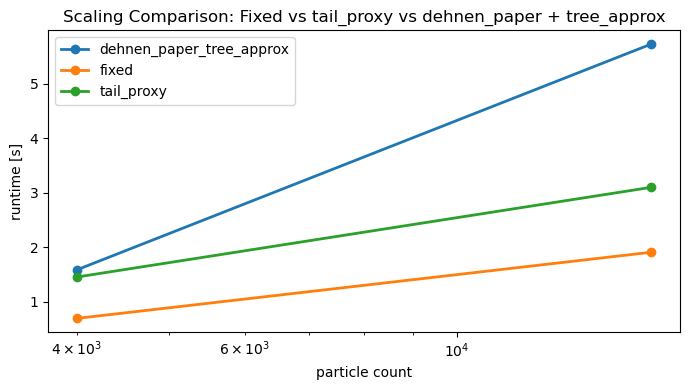

In [14]:
scaling_n_values = (4_000, 16_000)
scaling_theta = 0.6
scaling_leaf_size = 16
scaling_max_order = 4
scaling_warmup = 2
scaling_runs = 3
scaling_advanced = benchmark_runtime_config()

scaling_cases = [
    {
        'label': 'fixed',
        'adaptive_order': False,
        'adaptive_error_model': 'tail_proxy',
        'mac_force_scale_mode': 'prev',
        'dehnen_geometry_mode': 'tree_approx',
        'adaptive_eps': None,
    },
    {
        'label': 'tail_proxy',
        'adaptive_order': True,
        'adaptive_error_model': 'tail_proxy',
        'mac_force_scale_mode': 'prev',
        'dehnen_geometry_mode': 'tree_approx',
        'adaptive_eps': None,
    },
    {
        'label': 'dehnen_paper_tree_approx',
        'adaptive_order': True,
        'adaptive_error_model': 'dehnen_paper',
        'mac_force_scale_mode': 'paper',
        'dehnen_geometry_mode': 'tree_approx',
        'adaptive_eps': 1.0e-3,
    },
]

scaling_rows = []
for n in scaling_n_values:
    positions_scale, masses_scale, _ = generate_random_distribution(
        n,
        key=jax.random.PRNGKey(int(n)),
        dtype=jnp.float64,
    )
    for case in scaling_cases:
        solver = make_solver(
            adaptive_order=case['adaptive_order'],
            theta=scaling_theta,
            p_gears=(2, 3, 4),
            adaptive_error_model=case['adaptive_error_model'],
            mac_force_scale_mode=case['mac_force_scale_mode'],
            adaptive_eps=case['adaptive_eps'],
            dehnen_geometry_mode=case['dehnen_geometry_mode'],
            advanced=scaling_advanced,
        )
        timing = time_callable(
            lambda pos, mass: solver.compute_accelerations(
                pos, mass, leaf_size=scaling_leaf_size, max_order=scaling_max_order
            ),
            positions_scale,
            masses_scale,
            warmup=scaling_warmup,
            runs=scaling_runs,
        )
        scaling_rows.append({
            'n': n,
            'mode': case['label'],
            'runtime_s': float(timing.mean),
            'gear_counts': tuple(int(v) for v in getattr(solver._impl, '_recent_far_pairs_by_gear_counts', ())),
        })

scaling_rows

fig, ax = plt.subplots(figsize=(7, 4))
for mode in sorted({row['mode'] for row in scaling_rows}):
    rows = [row for row in scaling_rows if row['mode'] == mode]
    ax.plot([row['n'] for row in rows], [row['runtime_s'] for row in rows], marker='o', linewidth=2, label=mode)
ax.set_xscale('log')
ax.set_xlabel('particle count')
ax.set_ylabel('runtime [s]')
ax.set_title('Scaling Comparison: Fixed vs tail_proxy vs dehnen_paper + tree_approx')
ax.legend(loc='best')
fig.tight_layout()
plt.show()


## Fixed Error-Budget Comparison

For a paper-style comparison, raw runtime alone is not enough because the fixed and adaptive modes do not necessarily operate at the same error level.

This section compares configurations at a **fixed error budget**:

1. define a target error metric (here: `p99` relative acceleration error on the direct-sum problem),
2. evaluate a set of fixed and adaptive candidate configurations,
3. report the **fastest configuration that satisfies each target**.

This is closer to the logic used in Dehnen's paper: compare runtime at matched accuracy, not at arbitrary parameter settings.


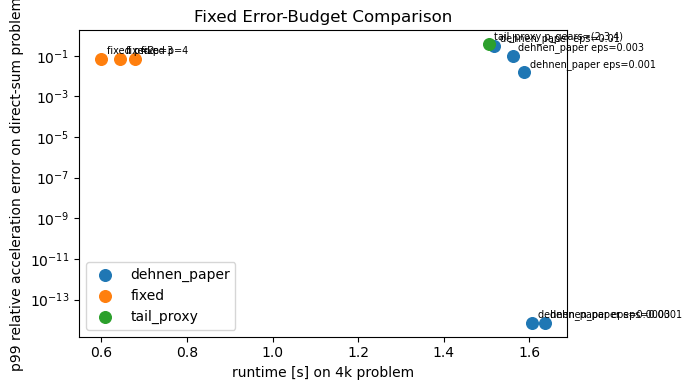

In [15]:
error_budget_theta = 0.6
error_budget_leaf_size = 16
error_budget_runtime_n = 4_000
error_budget_max_orders = (2, 3, 4)
error_budget_eps_grid = (1.0e-4, 3.0e-4, 1.0e-3, 3.0e-3, 1.0e-2)
error_budget_advanced = benchmark_runtime_config()

positions_runtime_budget, masses_runtime_budget, _ = generate_random_distribution(
    error_budget_runtime_n,
    key=jax.random.PRNGKey(2025),
    dtype=jnp.float64,
)

candidate_rows = []

for fixed_order in error_budget_max_orders:
    solver = make_solver(
        adaptive_order=False,
        theta=error_budget_theta,
        advanced=error_budget_advanced,
    )
    runtime_timing = time_callable(
        lambda pos, mass: solver.compute_accelerations(
            pos, mass, leaf_size=error_budget_leaf_size, max_order=fixed_order
        ),
        positions_runtime_budget,
        masses_runtime_budget,
        warmup=2,
        runs=2,
    )
    acc_eval = solver.compute_accelerations(
        positions_acc,
        masses_acc,
        leaf_size=leaf_size_accuracy,
        max_order=fixed_order,
    )
    rel_err, _, _ = relative_acceleration_errors(acc_eval, acc_ref)
    candidate_rows.append({
        'family': 'fixed',
        'label': f'fixed p={fixed_order}',
        'runtime_s': float(runtime_timing.mean),
        'gear_counts': tuple(),
        **summarize_errors(rel_err),
    })

tail_solver = make_solver(
    adaptive_order=True,
    theta=error_budget_theta,
    p_gears=(2, 3, 4),
    adaptive_error_model='tail_proxy',
    mac_force_scale_mode='prev',
    dehnen_geometry_mode='tree_approx',
    advanced=error_budget_advanced,
)
tail_runtime = time_callable(
    lambda pos, mass: tail_solver.compute_accelerations(
        pos, mass, leaf_size=error_budget_leaf_size, max_order=4
    ),
    positions_runtime_budget,
    masses_runtime_budget,
    warmup=2,
    runs=2,
)
tail_acc = tail_solver.compute_accelerations(
    positions_acc,
    masses_acc,
    leaf_size=leaf_size_accuracy,
    max_order=4,
)
tail_rel_err, _, _ = relative_acceleration_errors(tail_acc, acc_ref)
candidate_rows.append({
    'family': 'tail_proxy',
    'label': 'tail_proxy p_gears=(2,3,4)',
    'runtime_s': float(tail_runtime.mean),
    'gear_counts': tuple(int(v) for v in tail_solver._impl._recent_far_pairs_by_gear_counts),
    **summarize_errors(tail_rel_err),
})

for adaptive_eps in error_budget_eps_grid:
    solver = make_solver(
        adaptive_order=True,
        theta=error_budget_theta,
        p_gears=(2, 3, 4),
        adaptive_error_model='dehnen_paper',
        adaptive_eps=adaptive_eps,
        mac_force_scale_mode='paper',
        dehnen_geometry_mode='tree_approx',
        advanced=error_budget_advanced,
    )
    runtime_timing = time_callable(
        lambda pos, mass: solver.compute_accelerations(
            pos, mass, leaf_size=error_budget_leaf_size, max_order=4
        ),
        positions_runtime_budget,
        masses_runtime_budget,
        warmup=2,
        runs=2,
    )
    acc_eval = solver.compute_accelerations(
        positions_acc,
        masses_acc,
        leaf_size=leaf_size_accuracy,
        max_order=4,
    )
    rel_err, _, _ = relative_acceleration_errors(acc_eval, acc_ref)
    candidate_rows.append({
        'family': 'dehnen_paper',
        'label': f'dehnen_paper eps={adaptive_eps:g}',
        'runtime_s': float(runtime_timing.mean),
        'gear_counts': tuple(int(v) for v in solver._impl._recent_far_pairs_by_gear_counts),
        **summarize_errors(rel_err),
    })

candidate_rows

target_p99_values = (0.30, 0.10, 0.03, 1.0e-3, 1.0e-6)
budget_winners = []
for target in target_p99_values:
    feasible = [row for row in candidate_rows if row['p99'] <= target]
    if feasible:
        winner = min(feasible, key=lambda row: row['runtime_s'])
        budget_winners.append({
            'target_p99': target,
            'winner': winner['label'],
            'runtime_s': winner['runtime_s'],
            'p99': winner['p99'],
            'family': winner['family'],
        })
    else:
        budget_winners.append({
            'target_p99': target,
            'winner': None,
            'runtime_s': None,
            'p99': None,
            'family': None,
        })

budget_winners

fig, ax = plt.subplots(figsize=(7, 4))
for family in sorted({row['family'] for row in candidate_rows}):
    rows = [row for row in candidate_rows if row['family'] == family]
    ax.scatter([row['runtime_s'] for row in rows], [row['p99'] for row in rows], s=70, label=family)
for row in candidate_rows:
    ax.annotate(row['label'], (row['runtime_s'], row['p99']), textcoords='offset points', xytext=(4, 4), fontsize=7)
ax.set_xlabel('runtime [s] on 4k problem')
ax.set_ylabel('p99 relative acceleration error on direct-sum problem')
ax.set_yscale('log')
ax.set_title('Fixed Error-Budget Comparison')
ax.legend(loc='best')
fig.tight_layout()
plt.show()
